In [377]:
import math
import random
from collections import deque

import matplotlib.pyplot as plt
import torch
from tictactoeenv import TicTacToeEnv
from torch import nn, optim
from tqdm import tqdm

## Hyperparameters

In [590]:
INF = float("inf")

EPOCHS = 2_000
BATCH_SIZE = 8
N_HIDDEN = 600
REPLAY_BUFFER_SIZE = 10_000

ALPHA = 5e-5
GAMMA = 0.9
TAU = 0.05
LAMBDA = 5 / EPOCHS
EPSILON_MIN, EPSILON_MAX = 0.5, 1
epsilon = lambda epoch: (
    EPSILON_MIN + (EPSILON_MAX - EPSILON_MIN) * math.e ** (-LAMBDA * epoch)
)

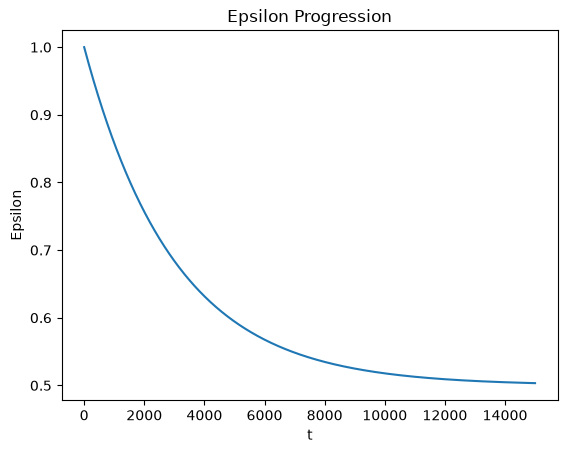

In [586]:
t = [i for i in range(EPOCHS)]
eps = [epsilon(i) for i in t]

plt.plot(t, eps)
plt.title("Epsilon Progression")
plt.xlabel("t")
plt.ylabel("Epsilon")
plt.show()

## DQN Building Blocks

In [587]:
State = tuple[int, ...]
Action = tuple[int, ...]
Reward = float
Done = bool

In [588]:
class DQN(nn.Module):
    def __init__(self, n_hidden: int):
        super().__init__()
        self.fc1 = nn.Linear(9, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.fc3 = nn.Linear(n_hidden, 9)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.tanh(self.fc3(x))
        return x

In [543]:
class ReplayBuffer:
    def __init__(self, max_size: int):
        self.buffer = deque(maxlen=max_size)

    def push(self, transitions: tuple[State, Action, Reward, State, Done]) -> None:
        self.buffer.append(transitions)

    def sample(
        self, sample_size: int
    ) -> list[tuple[State, Action, Reward, State, Done]]:
        return random.sample(self.buffer, k=sample_size)

    def __len__(self) -> int:
        return len(self.buffer)

## Train DQN

In [544]:
def batch_2_tensor(batch: list[tuple[State, Action, Reward, State, Done]], device):
    states = []
    actions = []
    rewards = []
    next_states = []
    dones = []
    for state, action, reward, next_state, done in batch:
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        next_states.append(next_state)
        dones.append(done)

    return (
        torch.tensor(states, dtype=torch.float).to(device),
        torch.tensor(actions).view(BATCH_SIZE, 1).to(device),
        torch.tensor(rewards, dtype=torch.float).view(BATCH_SIZE, 1).to(device),
        torch.tensor(next_states, dtype=torch.float).to(device),
        torch.tensor(dones).view(BATCH_SIZE, 1).to(device),
    )

In [579]:
env = TicTacToeEnv()
replay_buffer = ReplayBuffer(REPLAY_BUFFER_SIZE)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

dqn_target = DQN(N_HIDDEN).to(device)
dqn_online = DQN(N_HIDDEN).to(device)

criterion = nn.L1Loss()
optimizer = optim.Adam(lr=ALPHA, params=dqn_online.parameters())

In [591]:
loss_values = []
for epoch in tqdm(range(EPOCHS)):
    env.reset()
    done = False
    # Play one Game from Start to Finish
    while not done:
        # Find next Action
        state = env._get_state()
        if random.random() < epsilon(epoch):
            action = random.choice(env.legal_actions())  # Random Action
        else:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float).to(device)
                q_values = dqn_online(state_tensor)
                q_values[[a for a in range(9) if a not in env.legal_actions()]] = -INF
                action = torch.argmax(q_values).item()

        # Play Game + Fill Replay Buffer
        next_state, reward, done, _ = env.step(action)
        replay_buffer.push((state, action, reward, next_state, done))

        # Fill up Replay Buffer
        if len(replay_buffer) < REPLAY_BUFFER_SIZE:
            continue

        # DQN Inference
        batch = replay_buffer.sample(BATCH_SIZE)
        state_tensor, action_tensor, reward_tensor, next_state_tensor, done_tensor = (
            batch_2_tensor(batch, device)
        )
        q = dqn_online(state_tensor)
        with torch.no_grad():
            q_next_online = dqn_online(next_state_tensor)
            q_next_target = dqn_target(next_state_tensor)

        # Double DQN
        q_next = torch.gather(
            q_next_target, dim=1, index=torch.argmax(q_next_online, dim=1, keepdim=True)
        )

        target = reward_tensor - GAMMA * q_next
        target = torch.where(done_tensor, reward_tensor, target)
        y_hat = torch.gather(q, dim=1, index=action_tensor)

        # Train Online DQN
        loss = criterion(y_hat, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 200 == 0:
            loss_values.append(loss.item())

        # Update Target DQN (Polyak)
        # Only one out of 4 times to optimize performance (increased TAU)
        if (1 + epoch) % 4 == 0:
            with torch.no_grad():
                for dqn_online_params, dqn_target_params in zip(
                    dqn_online.parameters(), dqn_target.parameters()
                ):
                    dqn_target_params.copy_(
                        TAU * dqn_online_params + (1 - TAU) * dqn_target_params
                    )

100%|██████████| 2000/2000 [01:13<00:00, 27.39it/s]


## Evaluate

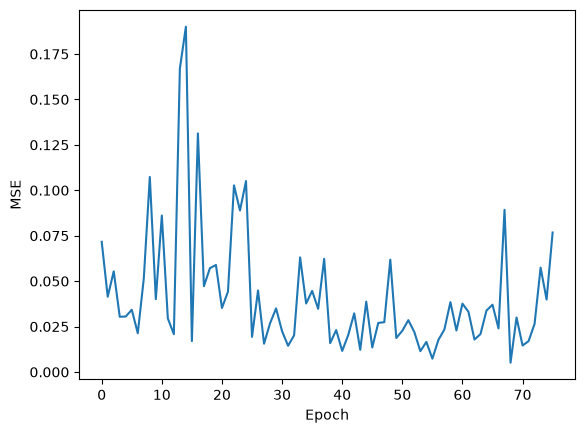

In [592]:
plt.plot(loss_values)
plt.xlabel("Epoch")
plt.ylabel("MSE")
# plt.yscale("log")
plt.show()

## Play Game

In [593]:
def enumerate_reachable_states() -> list[State]:
    """BFS all non-terminal board states reachable from an empty board."""
    start = tuple([0] * 9)
    visited = {start}
    frontier = [start]

    def is_terminal(state: State) -> bool:
        sim = TicTacToeEnv()
        sim.board = list(state)
        return sim._check_winner() is not None

    while frontier:
        state = frontier.pop()
        if is_terminal(state):
            continue  # terminal, nothing to expand

        player = 1 if state.count(1) == state.count(-1) else -1
        sim = TicTacToeEnv()
        sim.board = list(state)
        sim.current_player = player

        for action in sim.legal_actions():
            sim = TicTacToeEnv()
            sim.board = list(state)
            sim.current_player = player
            next_state, *_ = sim.step(action)
            if next_state not in visited:
                visited.add(next_state)
                frontier.append(next_state)

    return [s for s in visited if not is_terminal(s)]


def build_dqn_q_table(model: DQN, states: list[State]) -> dict[State, list[float]]:
    """Run inference for every reachable, non-terminal state.

    Q(s, a) is from the perspective of the player to move in s -- the same
    convention as the training targets, and the one q-learning's Q-table
    uses, so the two can share a visualization.
    """
    model.eval()
    table = {}
    with torch.no_grad():
        for state in states:
            q = model(torch.tensor(state, dtype=torch.float))
            table[state] = q.tolist()
    return table


reachable_states = enumerate_reachable_states()
dqn_q_table = build_dqn_q_table(dqn_online, reachable_states)

In [594]:
import json
import uuid

from IPython.display import HTML, display

DQN_GAME_TEMPLATE = """
<div id="ttt-__UID__" style="font-family: sans-serif;"></div>
<script>
(function () {
  const Q = __QTABLE__;
  const SCALE = __SCALE__;  // Q-values aren't bounded to [-1, 1] like a table, so scale colors relative to the strongest value seen
  const script = document.currentScript;
  const root = (script && script.parentNode && script.parentNode.querySelector("#ttt-__UID__"))
    || document.getElementById("ttt-__UID__");
  const LINES = [[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]];
  const SYM = {"1": "X", "-1": "O", "0": ""};
  let board, player, winner;

  function lerp(a, b, t) { return a.map((v, i) => Math.round(v + (b[i] - v) * t)); }

  function color(q) {
    const t = Math.max(-1, Math.min(1, q / SCALE));
    const red = [215, 48, 39], yellow = [255, 255, 191], green = [26, 152, 80];
    const rgb = t < 0 ? lerp(yellow, red, -t) : lerp(yellow, green, t);
    return "rgb(" + rgb.join(",") + ")";
  }

  function checkWinner() {
    for (const [a, b, c] of LINES) {
      if (board[a] !== 0 && board[a] === board[b] && board[a] === board[c]) return board[a];
    }
    return board.includes(0) ? null : 0;
  }

  function render() {
    const q = Q[board.join(",")] || Array(9).fill(0);
    root.replaceChildren();

    const grid = document.createElement("div");
    grid.style.cssText = "display: grid; grid-template-columns: repeat(3, 70px); grid-template-rows: repeat(3, 70px); gap: 4px;";
    board.forEach((mark, i) => {
      const cell = document.createElement("button");
      cell.dataset.cell = i;
      cell.style.cssText = "width: 70px; height: 70px; padding: 0; border: 1px solid #888; border-radius: 4px; color: #222; font-weight: bold;";
      if (mark !== 0 || winner !== null) {
        cell.textContent = SYM[mark];
        cell.style.fontSize = "28px";
        cell.style.background = "#ddd";
        cell.disabled = true;
      } else {
        cell.textContent = q[i].toFixed(2);
        cell.style.fontSize = "13px";
        cell.style.background = color(q[i]);
        cell.style.cursor = "pointer";
      }
      grid.appendChild(cell);
    });

    const status = document.createElement("p");
    status.style.margin = "8px 0";
    if (winner === null) status.textContent = "Player " + SYM[player] + " to move";
    else if (winner === 0) status.textContent = "Draw!";
    else status.textContent = "Player " + SYM[winner] + " wins!";

    const resetButton = document.createElement("button");
    resetButton.dataset.action = "reset";
    resetButton.textContent = "Reset";
    resetButton.style.cssText = "padding: 4px 12px; cursor: pointer;";

    root.append(grid, status, resetButton);
  }

  function play(i) {
    if (winner !== null || board[i] !== 0) return;
    board[i] = player;
    winner = checkWinner();
    if (winner === null) player = -player;
    render();
  }

  function reset() {
    board = Array(9).fill(0);
    player = 1;
    winner = null;
    render();
  }

  root.addEventListener("click", (event) => {
    const button = event.target.closest("button");
    if (!button || !root.contains(button)) return;
    if (button.dataset.action === "reset") reset();
    else if (button.dataset.cell !== undefined) play(Number(button.dataset.cell));
  });

  reset();
})();
</script>
"""


def play_interactive_dqn(q_table: dict[State, list[float]]) -> None:
    """Render a clickable Tic Tac Toe board showing the DQN's Q-values.

    Empty cells show the Q-value of that move for the player to move,
    colored from red (worst) over yellow (neutral) to green (best). Unlike
    the tabular Q-learning values, DQN outputs aren't bounded to [-1, 1], so
    colors are scaled relative to the largest magnitude in the table -- the
    printed number is always the raw value.
    """
    q_json = json.dumps(
        {
            ",".join(map(str, state)): [round(float(v), 4) for v in q]
            for state, q in q_table.items()
        }
    )
    scale = max((abs(v) for q in q_table.values() for v in q), default=1.0)
    html = (
        DQN_GAME_TEMPLATE.replace("__UID__", uuid.uuid4().hex)
        .replace("__QTABLE__", q_json)
        .replace("__SCALE__", str(scale))
    )
    display(HTML(html))

In [595]:
play_interactive_dqn(dqn_q_table)

## Why Tabular Q-Learning Beats This DQN Here

For a state space this small, the tabular approach has a structural advantage: it stores every one of the ~5,000 reachable states as its own independent table cell, so each state's value converges to the exact optimal-play answer with no interference from any other state.

The DQN instead has to represent all states with one shared, parametric function over 9 raw board cells. That function has no built-in notion of "these three cells form a line," so it must learn line/threat detection from scratch, and its smooth approximation struggles to reproduce the sharp jumps in tic-tac-toe's true value function (e.g. one non-center reply to a corner opening being a forced loss while the center is a draw). On top of that, most optimal-play states are near-neutral (value ≈ 0), so gradient signal is naturally weak there, while early states' correct values depend on a chain of bootstrapped estimates from several moves later -- any approximation bias in that chain compounds backward, leaving early/subtle positions blurrier than the table's exact values.